<a href="https://colab.research.google.com/github/zied3332/4TWIN2-2026-WeebGeeks-AI/blob/main/Employee_Segmentation_using_Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Block 1 — Title / Goal

In [ ]:
# ============================================================
# Objective 3: Employee Segmentation using Clustering
# Goal: Group employees into similar HR profiles using unsupervised learning
# ============================================================

# Block 2 — Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score

from scipy.cluster.hierarchy import linkage, dendrogram
from google.colab import files

# Block 3 — Upload and Load Dataset




In [ ]:

uploaded = files.upload()

df = pd.read_csv("Cleaned_HR_Data_Analysis.csv")

print("Dataset loaded successfully")
print("Dataset shape:", df.shape)

df.head()

Saving Cleaned_HR_Data_Analysis.csv to Cleaned_HR_Data_Analysis.csv
Dataset loaded successfully
Dataset shape: (2845, 28)


,Employee ID,StartDate,Title,BusinessUnit,EmployeeStatus,EmployeeType,PayZone,EmployeeClassificationType,DepartmentType,Division,...,Engagement Score,Satisfaction Score,Work-Life Balance Score,Training Date,Training Program Name,Training Type,Training Outcome,Training Duration(Days),Training Cost,Age
0,3427,20-Sep-19,Production Technician I,CCDR,Active,Contract,Zone C,Temporary,Production,Finance & Accounting,...,1,2,3,15-Jul-23,Leadership Development,Internal,Failed,2,606.11,50
1,3428,11-Feb-23,Production Technician I,EW,Active,Contract,Zone A,Part-Time,Production,Aerial,...,2,1,5,12-Sep-22,Customer Service,External,Incomplete,4,673.02,58
2,3429,10-Dec-18,Area Sales Manager,PL,Active,Full-Time,Zone B,Part-Time,Sales,General - Sga,...,1,2,1,13-Aug-22,Leadership Development,External,Failed,2,413.28,27
3,3430,21-Jun-21,Area Sales Manager,CCDR,Active,Contract,Zone A,Full-Time,Sales,Finance & Accounting,...,5,5,4,15-Dec-22,Project Management,External,Completed,3,663.78,23
4,3431,29-Jun-19,Area Sales Manager,TNS,Active,Contract,Zone A,Temporary,Sales,General - Con,...,2,5,3,13-Jul-23,Technical Skills,External,Failed,5,399.03,50


# Block 4 — Clean Dataset




In [ ]:
# Drop columns that are not useful for clustering
cols_to_drop = [
    "EmployeeCount",
    "StandardHours",
    "Over18",
    "EmployeeNumber",
    "Attrition"
]

df_clean = df.drop(columns=cols_to_drop, errors="ignore")

print("Shape after cleaning:", df_clean.shape)

Shape after cleaning: (2845, 28)


# Block 5 — Select HR Features




In [ ]:
selected_features = [
    "Age",
    "Education",
    "JobLevel",
    "MonthlyIncome",
    "TotalWorkingYears",
    "TrainingTimesLastYear",
    "WorkLifeBalance",
    "JobInvolvement",
    "PerformanceRating",
    "YearsAtCompany",
    "YearsInCurrentRole",
    "YearsSinceLastPromotion",
    "YearsWithCurrManager",
    "Current Employee Rating",
    "Engagement Score",
    "Satisfaction Score",
    "Work-Life Balance Score",
    "Training Duration(Days)",
    "Training Cost"
]

existing_features = [col for col in selected_features if col in df_clean.columns]

df_selected = df_clean[existing_features].copy()

print("Features found:", existing_features)
print("Selected shape:", df_selected.shape)

df_selected.head()

Features found: ['Age', 'Current Employee Rating', 'Engagement Score', 'Satisfaction Score', 'Work-Life Balance Score', 'Training Duration(Days)', 'Training Cost']
Selected shape: (2845, 7)


,Age,Current Employee Rating,Engagement Score,Satisfaction Score,Work-Life Balance Score,Training Duration(Days),Training Cost
0,50,4,1,2,3,2,606.11
1,58,3,2,1,5,4,673.02
2,27,4,1,2,1,2,413.28
3,23,2,5,5,4,3,663.78
4,50,3,2,5,3,5,399.03


# Block 6 — Encode Categorical Data


In [ ]:
df_encoded = df_selected.astype(float)

print("Encoded shape:", df_encoded.shape)
df_encoded.head()

Encoded shape: (2845, 7)


,Age,Current Employee Rating,Engagement Score,Satisfaction Score,Work-Life Balance Score,Training Duration(Days),Training Cost
0,50.0,4.0,1.0,2.0,3.0,2.0,606.11
1,58.0,3.0,2.0,1.0,5.0,4.0,673.02
2,27.0,4.0,1.0,2.0,1.0,2.0,413.28
3,23.0,2.0,5.0,5.0,4.0,3.0,663.78
4,50.0,3.0,2.0,5.0,3.0,5.0,399.03


In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_encoded)

print("X_scaled shape:", X_scaled.shape)

X_scaled shape: (2845, 7)


# Block 7 — Standardization

In [ ]:

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_encoded)

print("Scaling completed with StandardScaler")
print("X_scaled shape:", X_scaled.shape)

Scaling completed with StandardScaler
X_scaled shape: (2845, 7)


# Block 8 — PCA for Visualization

In [ ]:
# PCA for clustering: reduce noise
pca_clust = PCA(n_components=4, random_state=42)
X_reduced = pca_clust.fit_transform(X_scaled)

print("X_reduced shape:", X_reduced.shape)
print("Explained variance with 4 components:", pca_clust.explained_variance_ratio_.sum())

# PCA 2D only for visualization
pca_vis = PCA(n_components=2, random_state=42)
X_pca = pca_vis.fit_transform(X_scaled)

print("X_pca shape:", X_pca.shape)
print("Explained variance with 2 components:", pca_vis.explained_variance_ratio_.sum())

X_reduced shape: (2845, 4)
Explained variance with 4 components: 0.5885783973200285
X_pca shape: (2845, 2)
Explained variance with 2 components: 0.3021823443856013


# Block 9 — Choose Best K using Silhouette Score

In [ ]:
silhouette_scores = {}

for k in range(2, 7):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_reduced)
    score = silhouette_score(X_reduced, labels)
    silhouette_scores[k] = score
    print(f"K = {k} | Silhouette Score = {score:.4f}")

best_k = max(silhouette_scores, key=silhouette_scores.get)

print("Best K according to silhouette:", best_k)

K = 2 | Silhouette Score = 0.1727
K = 3 | Silhouette Score = 0.1679
K = 4 | Silhouette Score = 0.1779
K = 5 | Silhouette Score = 0.1858
K = 6 | Silhouette Score = 0.1840
Best K according to silhouette: 5


# Block 10 — Train Final K-Means Model

In [ ]:
# We choose 3 clusters for HR interpretation
final_k = 2

kmeans = KMeans(n_clusters=final_k, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_reduced)

df_selected["KMeans_Cluster"] = kmeans_labels

final_score = silhouette_score(X_reduced, kmeans_labels)

print("K-Means clustering completed")
print("Final K:", final_k)
print("Silhouette Score:", final_score)
print(df_selected["KMeans_Cluster"].value_counts())

K-Means clustering completed
Final K: 2
Silhouette Score: 0.17272985131188345
KMeans_Cluster
0    1457
1    1388
Name: count, dtype: int64


# Block 11 — Visualize K-Means Clusters

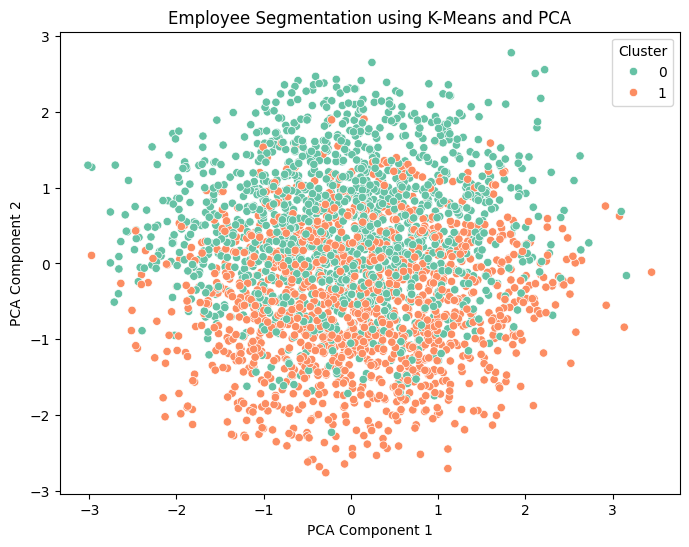

In [ ]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=df_selected["KMeans_Cluster"],
    palette="Set2"
)

plt.title("Employee Segmentation using K-Means and PCA")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend(title="Cluster")
plt.show()

# Block 12 — Agglomerative Clustering

In [ ]:
agg = AgglomerativeClustering(n_clusters=best_k)
agg_labels = agg.fit_predict(X_scaled)

df_selected["Agglomerative_Cluster"] = agg_labels

agg_score = silhouette_score(X_scaled, agg_labels)

print("Agglomerative clustering completed")
print("Silhouette Score:", agg_score)
print(df_selected["Agglomerative_Cluster"].value_counts())

Agglomerative clustering completed
Silhouette Score: 0.053018770962277535
Agglomerative_Cluster
0    720
1    614
2    555
4    521
3    435
Name: count, dtype: int64


# Block 13 — Dendrogram

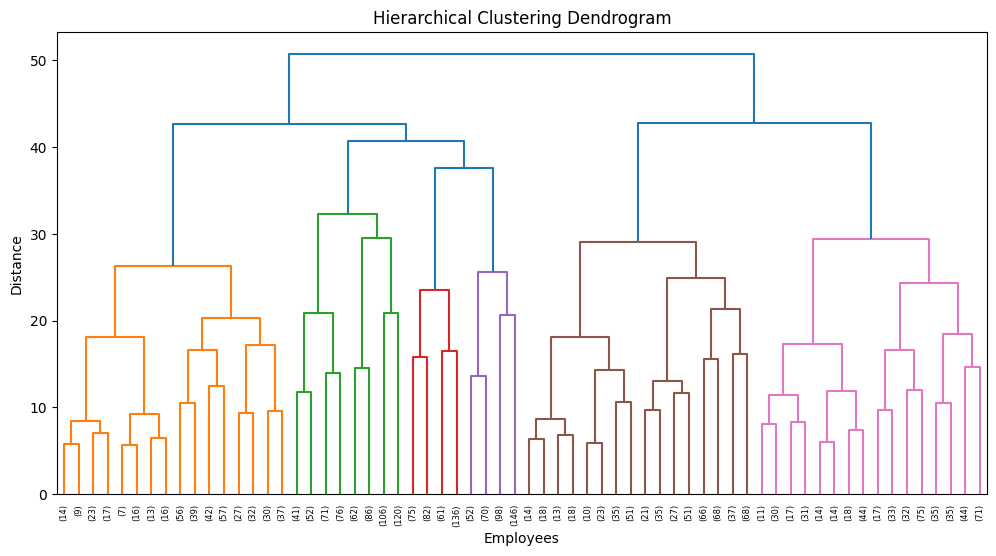

In [ ]:
linked = linkage(X_scaled, method="ward")

plt.figure(figsize=(12, 6))
dendrogram(linked, truncate_mode="level", p=5)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Employees")
plt.ylabel("Distance")
plt.show()

# Block 14 — Analyze Cluster Profiles

In [ ]:
cluster_profile = df_selected.groupby("KMeans_Cluster").mean(numeric_only=True)

cluster_profile

,Age,Current Employee Rating,Engagement Score,Satisfaction Score,Work-Life Balance Score,Training Duration(Days),Training Cost,Agglomerative_Cluster
KMeans_Cluster,,,,,,,,
0,44.136706,2.933262,3.600646,3.643703,2.745963,2.733046,771.919763,2.255113
1,54.415966,3.435924,2.921218,2.027311,3.875000,3.045168,552.843676,2.213235
2,49.661826,2.559129,2.326763,3.424274,2.348548,3.135892,360.713683,0.945021


# Block 15 — Final Summary

In [ ]:
print("Final Summary")
print("-------------")
print("Objective: Segment employees into similar HR profiles.")
print("Method: Unsupervised learning using K-Means and Agglomerative Clustering.")
print("Preprocessing: Feature selection, one-hot encoding, and standardization.")
print("PCA: Used to visualize high-dimensional employee data in 2D.")
print("Best number of clusters:", best_k)
print("K-Means Silhouette Score:", silhouette_scores[best_k])
print("Agglomerative Silhouette Score:", agg_score)

Final Summary
-------------
Objective: Segment employees into similar HR profiles.
Method: Unsupervised learning using K-Means and Agglomerative Clustering.
Preprocessing: Feature selection, one-hot encoding, and standardization.
PCA: Used to visualize high-dimensional employee data in 2D.
Best number of clusters: 2
K-Means Silhouette Score: 0.6368129163919378
Agglomerative Silhouette Score: 0.0678533498754195
